# Merge and Validate Renewable Energy Profiles

This notebook merges renewable energy profile data from 8 regions into global NetCDF and GeoJSON files, while validating country coverage using ISO3 codes.

**Objectives:**
1. Explore the structure of .nc, .geojson, and metadata .json files
2. Extract and validate ISO3 country codes across all regions
3. Merge regional datasets into global files with sequential loading
4. Generate country coverage reports and validate data integrity
5. Visualize merged results and identify missing country coverage

**Data Source:** `data/renewable_profiles/` directory with 8 regions:
- Africa, Australia, Central America, Central Asia
- Europe, North America, South America, South East Asia, West Asia

**Output Files:**
- `data/renewable_profiles_global_merged.nc` - Merged NetCDF dataset
- `data/renewable_profiles_global_merged.geojson` - Merged GeoJSON geometries
- `resources/renewable_profiles_merge_report.json` - Country validation report

In [2]:
# Import Required Libraries
import xarray as xr
import geopandas as gpd
import json
import pycountry
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
import warnings
import time
import psutil
import os

# Visualization
import matplotlib.pyplot as plt
from shapely.geometry import shape

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Set up paths
BASE_DIR = Path("../..")  # Notebook should be run from repo root
DATA_DIR = BASE_DIR / "data" / "renewable_profiles"
OUTPUT_DATA_DIR = BASE_DIR / "data"
RESOURCES_DIR = BASE_DIR / "resources"

# Ensure output directories exist
RESOURCES_DIR.mkdir(exist_ok=True, parents=True)

print(f"Data directory: {DATA_DIR}")
print(f"Data directory exists: {DATA_DIR.exists()}")
print(f"Output directory: {OUTPUT_DATA_DIR}")
print(f"Resources directory: {RESOURCES_DIR}")

# List all files in renewable_profiles
if DATA_DIR.exists():
    files = sorted(DATA_DIR.glob("*"))
    print(f"\nFound {len(files)} files in renewable_profiles:")
    for f in files:
        print(f"  {f.name}")

Data directory: ..\..\data\renewable_profiles
Data directory exists: True
Output directory: ..\..\data
Resources directory: ..\..\resources

Found 27 files in renewable_profiles:
  renewable_profiles_africa__20260417_155313.geojson
  renewable_profiles_africa__20260417_155313.nc
  renewable_profiles_africa__20260417_155313_metadata.json
  renewable_profiles_australia__20260420_172910.geojson
  renewable_profiles_australia__20260420_172910.nc
  renewable_profiles_australia__20260420_172910_metadata.json
  renewable_profiles_central_america__20260417_172618.geojson
  renewable_profiles_central_america__20260417_172618.nc
  renewable_profiles_central_america__20260417_172618_metadata.json
  renewable_profiles_central_asia__20260421_173248.geojson
  renewable_profiles_central_asia__20260421_173248.nc
  renewable_profiles_central_asia__20260421_173248_metadata.json
  renewable_profiles_europe__20260420_142941.geojson
  renewable_profiles_europe__20260420_142941.nc
  renewable_profiles_europ

## Section 1: Data Exploration

Load and inspect one sample file from each file type (.nc, .geojson, .json) to understand the data structure.

In [3]:
# 1.1 Explore NetCDF (.nc) file structure

# Find a sample .nc file
nc_files = sorted(DATA_DIR.glob("*.nc"))
sample_nc_file = nc_files[0] if nc_files else None

if sample_nc_file:
    print(f"Loading sample NetCDF file: {sample_nc_file.name}")
    ds = xr.open_dataset(sample_nc_file)
    print("\nNetCDF Dataset Dimensions:")
    print(f"  {ds.dims}")
    print("\nNetCDF Dataset Variables:")
    for var_name, var in ds.data_vars.items():
        print(f"  {var_name}: {var.shape} | dtype: {var.dtype}")
    print("\nNetCDF Coordinates:")
    for coord_name, coord in ds.coords.items():
        print(f"  {coord_name}: {coord.shape} | dtype: {coord.dtype}")
    print("\nNetCDF Attributes:")
    print(f"  {ds.attrs}")

    # Sample data
    print("\nSample Data:")
    print(f"  Technologies: {list(ds.coords['technology'].values)}")
    print(f"  Bus count: {len(ds.coords['bus'])}")
    print(f"  Hours per year: {len(ds.coords['hour'])}")
    print(
        f"  Capacity factor range: [{ds['capacity_factor'].min().values:.4f}, {ds['capacity_factor'].max().values:.4f}]"
    )
else:
    print("No .nc files found")

Loading sample NetCDF file: renewable_profiles_africa__20260417_155313.nc


c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\xarray\backends\plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)



NetCDF Dataset Dimensions:
  FrozenMappingWarningOnValuesAccess({'bus': 5296, 'technology': 3, 'hour': 8760, 'y_grid': 256, 'x_grid': 290})

NetCDF Dataset Variables:
  capacity_factor: (5296, 3, 8760) | dtype: float32
  p_nom_max: (5296, 3) | dtype: float32
  avg_cf: (5296, 3) | dtype: float32
  potential: (256, 290, 3) | dtype: float32
  weight: (5296,) | dtype: float32
  data_quality_flag: (5296, 3) | dtype: bool

NetCDF Coordinates:
  bus: (5296,) | dtype: <U18
  technology: (3,) | dtype: <U10
  hour: (8760,) | dtype: int32
  x_grid: (290,) | dtype: float64
  y_grid: (256,) | dtype: float64

NetCDF Attributes:
  {'schema_version': '1.0', 'created': '2026-04-17T15:53:13.510967', 'technologies': 'onwind,offwind-ac,solar', 'geohash_precision': np.int64(6), 'total_buses': np.int64(5296), 'complete_rate': '57.9%'}

Sample Data:
  Technologies: [np.str_('onwind'), np.str_('offwind-ac'), np.str_('solar')]
  Bus count: 5296
  Hours per year: 8760
  Capacity factor range: [0.0000, 1.0000]


In [4]:
# 1.2 Explore GeoJSON (.geojson) file structure

geojson_files = sorted(DATA_DIR.glob("*.geojson"))
sample_geojson_file = geojson_files[0] if geojson_files else None

if sample_geojson_file:
    print(f"Loading sample GeoJSON file: {sample_geojson_file.name}")
    gdf = gpd.read_file(sample_geojson_file)
    print(f"\nGeoDataFrame Shape: {gdf.shape}")
    print(f"\nColumns: {list(gdf.columns)}")
    print(f"\nData Types:\n{gdf.dtypes}")
    print("\nFirst 5 rows:")
    print(gdf[["bus_id", "country", "onshore_offshore", "area_km2", "geometry"]].head())

    # Sample properties
    print(f"\nUnique countries: {gdf['country'].nunique()}")
    print(f"Sample country codes: {gdf['country'].unique()[:10]}")
    print(f"Onshore/Offshore split: {gdf['onshore_offshore'].value_counts().to_dict()}")
    print(f"CRS: {gdf.crs}")
else:
    print("No .geojson files found")

Loading sample GeoJSON file: renewable_profiles_africa__20260417_155313.geojson


c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()



GeoDataFrame Shape: (5296, 8)

Columns: ['bus_id', 'pypsa_region_id', 'country', 'onshore_offshore', 'x_centroid', 'y_centroid', 'area_km2', 'geometry']

Data Types:
bus_id                object
pypsa_region_id       object
country               object
onshore_offshore      object
x_centroid           float64
y_centroid           float64
area_km2             float64
geometry            geometry
dtype: object

First 5 rows:
          bus_id country onshore_offshore    area_km2  \
0  GNQ_ON_s0r8wu     GNQ          onshore   921.48450   
1  GNQ_ON_s2218h     GNQ          onshore   493.58640   
2  GNQ_ON_s22031     GNQ          onshore   145.26703   
3  GNQ_ON_s0r7we     GNQ          onshore  1460.04490   
4  GNQ_ON_s0r4cs     GNQ          onshore  1142.17540   

                                            geometry  
0  POLYGON ((10.70416 1.68974, 10.93139 1.6683, 1...  
1  POLYGON ((11.30148 1.55584, 11.14498 1.6187, 1...  
2  POLYGON ((11.23415 1.39898, 11.30148 1.55584, ...  
3  POLYGO

In [5]:
# 1.3 Explore Metadata JSON files

json_files = sorted(DATA_DIR.glob("*_metadata.json"))
sample_json_file = json_files[0] if json_files else None

if sample_json_file:
    print(f"Loading sample metadata file: {sample_json_file.name}")
    with open(sample_json_file) as f:
        metadata = json.load(f)
    print("\nMetadata structure:")
    for key, value in metadata.items():
        print(f"  {key}: {value}")
else:
    print("No metadata .json files found")

# 1.4 Extract region names and file patterns
regions = set()
for f in DATA_DIR.glob("*.nc"):
    # Pattern: renewable_profiles_{REGION}__{TIMESTAMP}.nc
    parts = f.stem.split("__")
    if len(parts) >= 2:
        region = parts[0].replace("renewable_profiles_", "")
        regions.add(region)

print(f"\n\nRegions found in data directory: {sorted(regions)}")
print(f"Total regions: {len(regions)}")

Loading sample metadata file: renewable_profiles_africa__20260417_155313_metadata.json

Metadata structure:
  schema_version: 1.0
  timestamp: 2026-04-17T15:53:22.751191
  technologies: ['onwind', 'offwind-ac', 'solar']
  n_buses: 5296
  nc_file: renewable_profiles_africa__20260417_155313.nc
  geojson_file: renewable_profiles_africa__20260417_155313.geojson


Regions found in data directory: ['africa', 'australia', 'central_america', 'central_asia', 'europe', 'north_america', 'south_america', 'south_east_asia', 'west_asia']
Total regions: 9


## Section 2: Country Code Extraction & Validation

Extract all ISO3 country codes from bus_ids and GeoJSON properties, then validate against pycountry.

In [6]:
# 2.1 Helper function to extract ISO3 from bus_id


def extract_iso3_from_bus_id(bus_id):
    """
    Parse bus_id format: {ISO3}_{ON/OFF}_{geohash}
    Returns the ISO3 code (first 3 characters)
    """
    parts = str(bus_id).split("_")
    if len(parts) >= 1:
        return parts[0]
    return None


# Test with sample
if sample_geojson_file:
    sample_bus_ids = gdf["bus_id"].head(5)
    print("Sample bus_ids and extracted ISO3 codes:")
    for bus_id in sample_bus_ids:
        iso3 = extract_iso3_from_bus_id(bus_id)
        print(f"  {bus_id} -> {iso3}")

Sample bus_ids and extracted ISO3 codes:
  GNQ_ON_s0r8wu -> GNQ
  GNQ_ON_s2218h -> GNQ
  GNQ_ON_s22031 -> GNQ
  GNQ_ON_s0r7we -> GNQ
  GNQ_ON_s0r4cs -> GNQ


In [7]:
# 2.2 Extract all ISO3 codes from all GeoJSON files

print("Extracting ISO3 codes from all GeoJSON files...\n")

iso3_from_geojson = set()
iso3_from_bus_id = set()
iso3_counts = defaultdict(int)

for geojson_file in sorted(DATA_DIR.glob("*.geojson")):
    region_name = geojson_file.stem.split("__")[0].replace("renewable_profiles_", "")
    print(f"Processing {region_name}...")

    gdf_region = gpd.read_file(geojson_file)

    # Extract from 'country' column
    region_iso3_geojson = set(gdf_region["country"].dropna().unique())
    iso3_from_geojson.update(region_iso3_geojson)

    # Extract from bus_id
    region_iso3_bus_id = set(
        gdf_region["bus_id"].apply(extract_iso3_from_bus_id).unique()
    )
    iso3_from_bus_id.update(region_iso3_bus_id)

    # Count buses per country
    for iso3 in region_iso3_geojson:
        iso3_counts[iso3] += len(gdf_region[gdf_region["country"] == iso3])

    print(f"  Countries: {len(region_iso3_geojson)} | Buses: {len(gdf_region)}")

print(
    f"\nTotal unique ISO3 codes found in GeoJSON 'country' column: {len(iso3_from_geojson)}"
)
print(f"Total unique ISO3 codes from bus_ids: {len(iso3_from_bus_id)}")
print(f"Total buses across all regions: {sum(iso3_counts.values())}")
print(f"\nSample ISO3 codes: {sorted(list(iso3_from_geojson))[:20]}")

Extracting ISO3 codes from all GeoJSON files...

Processing africa...
  Countries: 54 | Buses: 5296
Processing australia...
  Countries: 14 | Buses: 2182
Processing central_america...
  Countries: 21 | Buses: 2475
Processing central_asia...
  Countries: 20 | Buses: 31442
Processing europe...
  Countries: 42 | Buses: 28363
Processing north_america...
  Countries: 15 | Buses: 28633
Processing south_america...
  Countries: 35 | Buses: 15715
Processing south_east_asia...
  Countries: 11 | Buses: 4283
Processing west_asia...
  Countries: 18 | Buses: 4442

Total unique ISO3 codes found in GeoJSON 'country' column: 194
Total unique ISO3 codes from bus_ids: 194
Total buses across all regions: 122831

Sample ISO3 codes: ['AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH']


In [8]:
# 2.3 Validate against pycountry

# Get all valid ISO3 codes from pycountry
valid_iso3_codes = {country.alpha_3 for country in pycountry.countries}
print(f"Total ISO3 codes in pycountry: {len(valid_iso3_codes)}\n")

# Find valid and invalid ISO3 codes in renewable profiles
iso3_in_renewable = iso3_from_geojson
iso3_valid = iso3_in_renewable & valid_iso3_codes
iso3_invalid = iso3_in_renewable - valid_iso3_codes
iso3_missing = valid_iso3_codes - iso3_in_renewable

print(f"Countries in renewable profiles: {len(iso3_valid)}")
print(f"Invalid ISO3 codes in renewable profiles: {len(iso3_invalid)}")
if iso3_invalid:
    print(f"  Invalid codes: {sorted(iso3_invalid)}")

print(f"\nCountries in pycountry but NOT in renewable profiles: {len(iso3_missing)}")
print(f"  Sample: {sorted(list(iso3_missing))[:20]}")

# Create validation summary dataframe
validation_df = pd.DataFrame(
    {
        "ISO3": sorted(iso3_valid),
        "Bus_Count": [iso3_counts.get(iso3, 0) for iso3 in sorted(iso3_valid)],
        "In_Pycountry": True,
    }
)

print("\nCountry Coverage Summary:")
print(f"  Total countries with renewable profiles: {len(validation_df)}")
print(f"  Total buses: {validation_df['Bus_Count'].sum()}")
print(f"  Avg buses per country: {validation_df['Bus_Count'].mean():.1f}")
print(f"  Min buses per country: {validation_df['Bus_Count'].min()}")
print(f"  Max buses per country: {validation_df['Bus_Count'].max()}")

print("\nTop 10 countries by bus count:")
print(validation_df.nlargest(10, "Bus_Count")[["ISO3", "Bus_Count"]])

Total ISO3 codes in pycountry: 249

Countries in renewable profiles: 194
Invalid ISO3 codes in renewable profiles: 0

Countries in pycountry but NOT in renewable profiles: 55
  Sample: ['ABW', 'AIA', 'ALA', 'ASM', 'ATA', 'ATF', 'BES', 'BLM', 'BMU', 'BVT', 'CCK', 'COK', 'CUW', 'CXR', 'CYM', 'ESH', 'FLK', 'FRO', 'GGY', 'GIB']

Country Coverage Summary:
  Total countries with renewable profiles: 194
  Total buses: 122831
  Avg buses per country: 633.1
  Min buses per country: 1
  Max buses per country: 30853

Top 10 countries by bus count:
    ISO3  Bus_Count
183  USA      30853
32   CHN      15238
77   IND       8471
29   CAN       4488
23   BRA       4198
44   DEU       3141
58   FRA       2983
111  MEX       2525
86   JPN       2475
83   ITA       2452


## Section 3: Merge Logic

Load all regional files sequentially and merge into global .nc and .geojson files.

In [10]:
# 3.1 Define helper functions for loading regional data


def get_latest_file(directory, pattern):
    """Get the most recently modified file matching pattern (by timestamp in filename)"""
    files = sorted(directory.glob(pattern))
    if files:
        return files[-1]  # Timestamp in filename ensures latest is last when sorted
    return None


def load_region_nc(region_dir, region_name):
    """Load NetCDF file for a region"""
    nc_file = get_latest_file(region_dir, f"renewable_profiles_{region_name}__*.nc")
    if nc_file:
        return xr.open_dataset(nc_file)
    return None


def load_region_geojson(region_dir, region_name):
    """Load GeoJSON file for a region as GeoDataFrame"""
    geojson_file = get_latest_file(
        region_dir, f"renewable_profiles_{region_name}__*.geojson"
    )
    if geojson_file:
        return gpd.read_file(geojson_file)
    return None


def load_region_metadata(region_dir, region_name):
    """Load metadata JSON for a region"""
    json_file = get_latest_file(
        region_dir, f"renewable_profiles_{region_name}__*_metadata.json"
    )
    if json_file:
        with open(json_file) as f:
            return json.load(f)
    return None


def create_global_grid(resolution=0.25):
    """
    Create a global grid at specified resolution (degrees)
    Default 0.25° gives ~1440 x 720 grid cells

    Returns:
        x_global, y_global: 1D arrays of global grid coordinates
    """
    x_global = np.arange(-180, 180 + resolution, resolution)  # Longitude: -180 to 180
    y_global = np.arange(-90, 90 + resolution, resolution)  # Latitude: -90 to 90
    return x_global, y_global


def place_regional_potential_on_global_grid(
    potential_regional, x_regional, y_regional, x_global, y_global, technology_dim
):
    """
    Place regional potential data onto global grid with NaN fill.

    Parameters:
        potential_regional: [y_regional, x_regional, technology]
        x_regional, y_regional: Regional grid coordinates
        x_global, y_global: Global grid coordinates
        technology_dim: Index of technology dimension

    Returns:
        potential_global: [y_global, x_global, technology] filled with NaN + regional data
    """
    # Initialize global grid with NaN
    n_tech = potential_regional.shape[technology_dim]
    potential_global = np.full(
        (len(y_global), len(x_global), n_tech), np.nan, dtype=np.float32
    )

    # Find indices where regional grid maps to global grid
    x_indices = np.searchsorted(x_global, x_regional)
    y_indices = np.searchsorted(y_global, y_regional)

    # Handle boundary cases (shouldn't happen if grids are within [-180,180] x [-90,90])
    valid_x = (x_indices >= 0) & (x_indices < len(x_global))
    valid_y = (y_indices >= 0) & (y_indices < len(y_global))

    if not (valid_x.all() and valid_y.all()):
        print("    ⚠️ Warning: Some grid cells outside global bounds")

    # Place regional data into global grid
    for i, y_idx in enumerate(y_indices):
        for j, x_idx in enumerate(x_indices):
            if 0 <= x_idx < len(x_global) and 0 <= y_idx < len(y_global):
                potential_global[y_idx, x_idx, :] = potential_regional[i, j, :]

    return potential_global


print("Helper functions defined successfully")
print("\n✅ REVISED MERGE STRATEGY: Global Grid with NaN Fill")
print("=" * 70)
print("Approach: Create global 0.25° grid covering entire world")
print("  1. Build uniform grid: -180° to 180° (lon), -90° to 90° (lat)")
print("  2. Fill with NaN globally")
print("  3. Place each region's potential data into corresponding cells")
print("  4. Result: Single global potential variable with NaN where no data")
print("\nBenefits:")
print("  ✓ All data (including potential) in single merged .nc file")
print("  ✓ Standard gridded format suitable for further analysis")
print("  ✓ Can interpolate/analyze global grid uniformly")
print("  ✓ Cleaner API - no separate grid handling needed")

Helper functions defined successfully

✅ REVISED MERGE STRATEGY: Global Grid with NaN Fill
Approach: Create global 0.25° grid covering entire world
  1. Build uniform grid: -180° to 180° (lon), -90° to 90° (lat)
  2. Fill with NaN globally
  3. Place each region's potential data into corresponding cells
  4. Result: Single global potential variable with NaN where no data

Benefits:
  ✓ All data (including potential) in single merged .nc file
  ✓ Standard gridded format suitable for further analysis
  ✓ Can interpolate/analyze global grid uniformly
  ✓ Cleaner API - no separate grid handling needed


In [11]:
# 3.2 Sequential merge of all regional files

print("Starting merge process...")
print("=" * 70)

# Define regions in the order they appear in the data
regions_to_merge = sorted(
    [
        "africa",
        "australia",
        "central_america",
        "central_asia",
        "europe",
        "north_america",
        "south_america",
        "south_east_asia",
        "west_asia",
    ]
)

# Initialize accumulators
nc_datasets_bus_vars = []  # Bus-level variables for concat
potential_data_by_region = {}  # Store potential data per region
global_grid_extents = {  # Track bounds for global grid
    "x_min": 180,
    "x_max": -180,
    "y_min": 90,
    "y_max": -90,
}
geojson_features_list = []
merge_metadata = {
    "regions_processed": [],
    "total_buses": 0,
    "regional_bus_counts": {},
    "iso3_counts": {},
    "timestamps": {},
    "regional_techs": {},  # Store technology list per region
    "merge_timestamp": pd.Timestamp.now().isoformat(),
    "merge_strategy": "All variables merged including global potential grid with NaN fill",
}

# Track memory usage
start_memory = psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024  # MB
start_time = time.time()

# Merge loop
for region_name in regions_to_merge:
    print(f"\nProcessing region: {region_name}")

    # Load regional data
    ds_region = load_region_nc(DATA_DIR, region_name)
    gdf_region = load_region_geojson(DATA_DIR, region_name)
    meta_region = load_region_metadata(DATA_DIR, region_name)

    if ds_region is None or gdf_region is None:
        print(f"  ⚠ Skipping {region_name}: missing .nc or .geojson files")
        continue

    # Count buses
    n_buses = len(ds_region.coords["bus"])
    print(f"  ✓ Loaded {region_name}: {n_buses} buses, {len(gdf_region)} features")

    # Store technology information for this region
    if "technology" in ds_region.coords:
        region_tech_list = list(ds_region.coords["technology"].values)
        merge_metadata["regional_techs"][region_name] = region_tech_list
        print(f"    Technologies: {region_tech_list}")

    # Log grid information
    if "x_grid" in ds_region.coords and "y_grid" in ds_region.coords:
        x_grid_region = ds_region.coords["x_grid"].values
        y_grid_region = ds_region.coords["y_grid"].values

        print(f"    Grid size: {len(x_grid_region)} × {len(y_grid_region)} cells")
        print(f"    X range: [{x_grid_region.min():.2f}, {x_grid_region.max():.2f}]")
        print(f"    Y range: [{y_grid_region.min():.2f}, {y_grid_region.max():.2f}]")

        # Update global extent
        global_grid_extents["x_min"] = min(
            global_grid_extents["x_min"], x_grid_region.min()
        )
        global_grid_extents["x_max"] = max(
            global_grid_extents["x_max"], x_grid_region.max()
        )
        global_grid_extents["y_min"] = min(
            global_grid_extents["y_min"], y_grid_region.min()
        )
        global_grid_extents["y_max"] = max(
            global_grid_extents["y_max"], y_grid_region.max()
        )

        # Store potential data for later global grid assembly
        if "potential" in ds_region.data_vars:
            potential_data_by_region[region_name] = {
                "data": ds_region["potential"].values,
                "x_grid": x_grid_region,
                "y_grid": y_grid_region,
            }
            print("    ✓ Stored potential data for grid assembly")

    # Store metadata
    if meta_region:
        merge_metadata["timestamps"][region_name] = meta_region.get(
            "timestamp", "unknown"
        )

    # Validate consistency
    if n_buses != len(gdf_region):
        print(
            f"  ⚠ Warning: NetCDF has {n_buses} buses but GeoJSON has {len(gdf_region)} features"
        )

    # Extract only bus-level variables (exclude grid-dependent 'potential')
    data_vars_to_keep = [
        var
        for var in ds_region.data_vars
        if "x_grid" not in ds_region[var].dims and "y_grid" not in ds_region[var].dims
    ]

    # Create subset dataset with bus-level variables only
    ds_region_bus_vars = ds_region[data_vars_to_keep]

    # Accumulate bus-level NetCDF datasets
    nc_datasets_bus_vars.append(ds_region_bus_vars)

    print(f"    Variables to merge (bus-level): {data_vars_to_keep}")

    # Accumulate GeoJSON features
    for idx, row in gdf_region.iterrows():
        feature = {
            "type": "Feature",
            "geometry": row.geometry.__geo_interface__,
            "properties": {k: v for k, v in row.items() if k != "geometry"},
        }
        geojson_features_list.append(feature)

    # Track regional stats
    merge_metadata["regional_bus_counts"][region_name] = n_buses
    merge_metadata["regions_processed"].append(region_name)

    # Track ISO3 counts
    for iso3 in gdf_region["country"].unique():
        if pd.notna(iso3):
            count = len(gdf_region[gdf_region["country"] == iso3])
            merge_metadata["iso3_counts"][iso3] = (
                merge_metadata["iso3_counts"].get(iso3, 0) + count
            )

    # Memory check
    current_memory = psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024
    print(
        f"  Memory: {current_memory:.1f} MB (delta: {current_memory - start_memory:+.1f} MB)"
    )

print(f"\n{'=' * 70}")
print(f"Loaded {len(nc_datasets_bus_vars)} regions")
print(f"Stored potential data for {len(potential_data_by_region)} regions")
merge_metadata["total_buses"] = sum(merge_metadata["regional_bus_counts"].values())
print(f"Total buses to merge: {merge_metadata['total_buses']}")
print("\nGlobal grid extent (from regional data):")
print(f"  X: [{global_grid_extents['x_min']:.2f}, {global_grid_extents['x_max']:.2f}]")
print(f"  Y: [{global_grid_extents['y_min']:.2f}, {global_grid_extents['y_max']:.2f}]")
print("\nNext: Will create global 0.25° grid and assemble potential variable")

Starting merge process...

Processing region: africa
  ✓ Loaded africa: 5296 buses, 5296 features
    Technologies: [np.str_('onwind'), np.str_('offwind-ac'), np.str_('solar')]
    Grid size: 290 × 256 cells
    X range: [-19.50, 67.20]
    Y range: [-37.50, 39.00]
    ✓ Stored potential data for grid assembly
    Variables to merge (bus-level): ['capacity_factor', 'p_nom_max', 'avg_cf', 'weight', 'data_quality_flag']
  Memory: 921.7 MB (delta: +8.9 MB)

Processing region: australia
  ✓ Loaded australia: 2182 buses, 2182 features
    Technologies: [np.str_('onwind'), np.str_('solar')]
    Grid size: 403 × 193 cells
    X range: [80.10, 179.70]
    Y range: [-49.80, 7.80]
    ✓ Stored potential data for grid assembly
    Variables to merge (bus-level): ['capacity_factor', 'p_nom_max', 'avg_cf', 'weight', 'data_quality_flag']
  Memory: 938.3 MB (delta: +25.5 MB)

Processing region: central_america
  ✓ Loaded central_america: 2475 buses, 2475 features
    Technologies: [np.str_('onwind'),

In [12]:
# 3.3 Concatenate NetCDF datasets (bus-level variables only)

print("\nConcatenating NetCDF datasets (bus-level variables)...")
if nc_datasets_bus_vars:
    # Concatenate along the 'bus' dimension
    ds_merged = xr.concat(nc_datasets_bus_vars, dim="bus")
    print(f"✓ Merged NetCDF dimensions: {dict(ds_merged.dims)}")
    print(f"✓ Merged NetCDF variables: {list(ds_merged.data_vars)}")
    print(f"✓ Merged NetCDF coordinates: {list(ds_merged.coords)}")
else:
    print("✗ No datasets to merge!")
    ds_merged = None


Concatenating NetCDF datasets (bus-level variables)...


C:\Users\JanLeopoldTautorus\AppData\Local\Temp\ipykernel_4816\3622988324.py:6: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'technology' ('technology',) The recommendation is to set join explicitly for this case.
  ds_merged = xr.concat(nc_datasets_bus_vars, dim='bus')


✓ Merged NetCDF dimensions: {'bus': 122831, 'technology': 3, 'hour': 8760}
✓ Merged NetCDF variables: ['capacity_factor', 'p_nom_max', 'avg_cf', 'weight', 'data_quality_flag']
✓ Merged NetCDF coordinates: ['technology', 'hour', 'bus']


C:\Users\JanLeopoldTautorus\AppData\Local\Temp\ipykernel_4816\3622988324.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"✓ Merged NetCDF dimensions: {dict(ds_merged.dims)}")


In [13]:
# 3.3b Assemble global potential grid

print("\nAssembling global potential grid...")
print("=" * 70)

if len(potential_data_by_region) > 0:
    # Create global grid at 0.25° resolution
    x_global, y_global = create_global_grid(resolution=0.25)
    print(f"✓ Created global grid: {len(x_global)} × {len(y_global)} cells")
    print(f"  X: [{x_global.min():.2f}, {x_global.max():.2f}] (longitude)")
    print(f"  Y: [{y_global.min():.2f}, {y_global.max():.2f}] (latitude)")

    # Get technology list from merged dataset
    tech_list = list(ds_merged.coords["technology"].values)
    n_technologies = len(tech_list)
    print(f"✓ Target technologies: {tech_list}")

    # Initialize global potential grid with NaN
    potential_global = np.full(
        (len(y_global), len(x_global), n_technologies), np.nan, dtype=np.float32
    )
    print(f"✓ Initialized global potential array: {potential_global.shape}")

    # Track regions by technology coverage
    region_tech_info = {}

    # Place each region's potential into global grid
    print("\nPlacing regional potential data into global grid...")
    for region_name, region_pot in potential_data_by_region.items():
        print(f"  Processing {region_name}...", end=" ")

        x_grid = region_pot["x_grid"]
        y_grid = region_pot["y_grid"]
        potential_region = region_pot["data"]

        # Check shape of regional potential
        n_tech_region = (
            potential_region.shape[2] if len(potential_region.shape) == 3 else 1
        )
        print(f"({n_tech_region} technologies)", end=" ")

        # Try to get technology list from region metadata (stored earlier)
        if region_name in merge_metadata.get("regional_techs", {}):
            region_tech_list = merge_metadata["regional_techs"][region_name]
        else:
            # Infer technologies: assume first n_tech_region techs from global list
            region_tech_list = tech_list[:n_tech_region]

        # Map regional technologies to global indices
        tech_mapping = {}
        for local_idx, tech in enumerate(region_tech_list):
            if tech in tech_list:
                global_idx = tech_list.index(tech)
                tech_mapping[local_idx] = global_idx
            else:
                print(f"\n    ⚠️ Warning: Unknown technology '{tech}' in {region_name}")

        print(f"→ Tech mapping: {tech_mapping}", end=" ")

        # Find indices in global grid
        x_idx = np.searchsorted(x_global, x_grid)
        y_idx = np.searchsorted(y_global, y_grid)

        # Place data into global grid (only place known technologies)
        for iy, y_i in enumerate(y_idx):
            for ix, x_i in enumerate(x_idx):
                if 0 <= x_i < len(x_global) and 0 <= y_i < len(y_global):
                    # Map regional tech indices to global indices
                    for local_tech_idx, global_tech_idx in tech_mapping.items():
                        potential_global[y_i, x_i, global_tech_idx] = potential_region[
                            iy, ix, local_tech_idx
                        ]

        # Count filled cells
        filled_cells = (~np.isnan(potential_global)).sum(axis=2).sum()
        print(f"✓ ({filled_cells} cells filled)")

        region_tech_info[region_name] = {
            "n_technologies": n_tech_region,
            "technologies": region_tech_list.tolist()
            if hasattr(region_tech_list, "tolist")
            else list(region_tech_list),
            "tech_mapping": tech_mapping,
        }

    # Count global coverage
    total_cells = len(x_global) * len(y_global)
    filled_cells = (
        ~np.isnan(potential_global[:, :, 0])
    ).sum()  # Check first technology
    coverage_pct = (filled_cells / total_cells) * 100
    print(
        f"\n✓ Global coverage: {filled_cells}/{total_cells} cells ({coverage_pct:.2f}%)"
    )

    # Add potential to merged dataset
    print("\n✓ Adding potential to merged dataset...")
    ds_merged["potential"] = xr.DataArray(
        potential_global,
        coords={
            "y_grid": y_global,
            "x_grid": x_global,
            "technology": ds_merged.coords["technology"].values,
        },
        dims=["y_grid", "x_grid", "technology"],
    )
    print("✓ Merged dataset now includes potential variable")

    # Store grid info in metadata
    merge_metadata["global_grid"] = {
        "resolution_degrees": 0.25,
        "x_range": [float(x_global.min()), float(x_global.max())],
        "y_range": [float(y_global.min()), float(y_global.max())],
        "grid_size": [len(x_global), len(y_global)],
        "coverage_percent": coverage_pct,
        "fill_value": "NaN where no data available",
    }

    merge_metadata["regional_technology_coverage"] = region_tech_info

    print("\n📊 Technology Coverage by Region:")
    for region, info in region_tech_info.items():
        print(
            f"  {region}: {info['n_technologies']} technologies - {info['technologies']}"
        )

else:
    print("⚠️ No potential data found to assemble global grid")


Assembling global potential grid...
✓ Created global grid: 1441 × 721 cells
  X: [-180.00, 180.00] (longitude)
  Y: [-90.00, 90.00] (latitude)
✓ Target technologies: [np.str_('offwind-ac'), np.str_('onwind'), np.str_('solar')]
✓ Initialized global potential array: (721, 1441, 3)

Placing regional potential data into global grid...
  Processing africa... (3 technologies) → Tech mapping: {0: 1, 1: 0, 2: 2} ✓ (200114 cells filled)
  Processing australia... (2 technologies) → Tech mapping: {0: 1, 1: 2} ✓ (354128 cells filled)
  Processing central_america... (3 technologies) → Tech mapping: {0: 1, 1: 0, 2: 2} ✓ (411772 cells filled)
  Processing central_asia... (2 technologies) → Tech mapping: {0: 1, 1: 2} ✓ (523094 cells filled)
  Processing europe... (3 technologies) → Tech mapping: {0: 1, 1: 0, 2: 2} ✓ (604225 cells filled)
  Processing north_america... (2 technologies) → Tech mapping: {0: 1, 1: 2} ✓ (758053 cells filled)
  Processing south_america... (3 technologies) → Tech mapping: {0

In [14]:
# 3.4 Create merged GeoJSON

print("\nCreating merged GeoJSON...")
geojson_merged = {"type": "FeatureCollection", "features": geojson_features_list}

print(f"✓ Merged GeoJSON has {len(geojson_features_list)} features")

# Convert to GeoDataFrame for validation
gdf_merged = gpd.GeoDataFrame.from_features(geojson_merged["features"], crs="EPSG:4326")
print(f"✓ Merged GeoDataFrame shape: {gdf_merged.shape}")
print(f"✓ Columns: {list(gdf_merged.columns)}")


Creating merged GeoJSON...
✓ Merged GeoJSON has 122831 features
✓ Merged GeoDataFrame shape: (122831, 8)
✓ Columns: ['geometry', 'bus_id', 'pypsa_region_id', 'country', 'onshore_offshore', 'x_centroid', 'y_centroid', 'area_km2']


In [15]:
# 3.5 Write merged files to disk

print("\nWriting merged files to disk...")

# Write NetCDF
if ds_merged is not None:
    output_nc_file = OUTPUT_DATA_DIR / "renewable_profiles_global_merged.nc"
    print(f"  Writing {output_nc_file.name}...")
    ds_merged.to_netcdf(output_nc_file)
    file_size_mb = output_nc_file.stat().st_size / 1024 / 1024
    print(f"  ✓ Wrote {output_nc_file.name} ({file_size_mb:.1f} MB)")

# Write GeoJSON
output_geojson_file = OUTPUT_DATA_DIR / "renewable_profiles_global_merged.geojson"
print(f"  Writing {output_geojson_file.name}...")
with open(output_geojson_file, "w") as f:
    json.dump(geojson_merged, f)
file_size_mb = output_geojson_file.stat().st_size / 1024 / 1024
print(f"  ✓ Wrote {output_geojson_file.name} ({file_size_mb:.1f} MB)")

# Write metadata report
output_report_file = RESOURCES_DIR / "renewable_profiles_merge_report.json"
print(f"  Writing {output_report_file.name}...")
with open(output_report_file, "w") as f:
    json.dump(merge_metadata, f, indent=2, default=str)
print(f"  ✓ Wrote {output_report_file.name}")

# Summary
elapsed_time = time.time() - start_time
final_memory = psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024
print(f"\n{'=' * 70}")
print("Merge complete!")
print(f"  Elapsed time: {elapsed_time:.1f} seconds")
print(f"  Memory used: {final_memory - start_memory:.1f} MB")
print(f"  Output files created in {OUTPUT_DATA_DIR}")
print(f"  Report file created in {RESOURCES_DIR}")
print("\n✅ All variables (including global potential grid) merged in single .nc file")


Writing merged files to disk...
  Writing renewable_profiles_global_merged.nc...
  ✓ Wrote renewable_profiles_global_merged.nc (3658.9 MB)
  Writing renewable_profiles_global_merged.geojson...
  ✓ Wrote renewable_profiles_global_merged.geojson (116.3 MB)
  Writing renewable_profiles_merge_report.json...
  ✓ Wrote renewable_profiles_merge_report.json

Merge complete!
  Elapsed time: 373.0 seconds
  Memory used: 12381.4 MB
  Output files created in ..\..\data
  Report file created in ..\..\resources

✅ All variables (including global potential grid) merged in single .nc file


## Section 4: Validation & Reporting

Validate merge integrity, generate country coverage reports, and visualize results.

In [16]:
# 4.1 Validate merge integrity

print("Validating merge integrity...")
print("=" * 70)

validation_checks = {}

# Check 1: Bus count consistency
expected_bus_count = sum(merge_metadata["regional_bus_counts"].values())
actual_bus_count = len(ds_merged.coords["bus"]) if ds_merged is not None else 0
check1 = expected_bus_count == actual_bus_count
validation_checks["Bus count match"] = {
    "passed": check1,
    "expected": expected_bus_count,
    "actual": actual_bus_count,
}
print(
    f"✓ Bus count consistency: {expected_bus_count} == {actual_bus_count}: {'PASS' if check1 else 'FAIL'}"
)

# Check 2: GeoJSON feature count vs NetCDF bus count
geojson_count = len(gdf_merged) if gdf_merged is not None else 0
check2 = geojson_count == actual_bus_count
validation_checks["GeoJSON-NetCDF count match"] = {
    "passed": check2,
    "geojson_features": geojson_count,
    "netcdf_buses": actual_bus_count,
}
print(
    f"✓ GeoJSON-NetCDF consistency: {geojson_count} features == {actual_bus_count} buses: {'PASS' if check2 else 'FAIL'}"
)

# Check 3: Dimension preservation
if ds_merged is not None:
    check3 = (
        "technology" in ds_merged.coords and len(ds_merged.coords["technology"]) == 3
    )
    check4 = "hour" in ds_merged.coords and len(ds_merged.coords["hour"]) == 8760
    validation_checks["Technology dimension"] = {
        "passed": check3,
        "expected": 3,
        "actual": len(ds_merged.coords["technology"])
        if "technology" in ds_merged.coords
        else 0,
    }
    validation_checks["Hour dimension"] = {
        "passed": check4,
        "expected": 8760,
        "actual": len(ds_merged.coords["hour"]) if "hour" in ds_merged.coords else 0,
    }
    print(
        f"✓ Technology dimension: {3} == {len(ds_merged.coords['technology'])}: {'PASS' if check3 else 'FAIL'}"
    )
    print(
        f"✓ Hour dimension: {8760} == {len(ds_merged.coords['hour'])}: {'PASS' if check4 else 'FAIL'}"
    )

# Check 4: No duplicate bus_ids
if gdf_merged is not None:
    n_unique = gdf_merged["bus_id"].nunique()
    n_total = len(gdf_merged)
    check5 = n_unique == n_total
    validation_checks["No duplicate bus_ids"] = {
        "passed": check5,
        "total_buses": n_total,
        "unique_buses": n_unique,
    }
    print(
        f"✓ Duplicate bus_ids: {n_unique} unique == {n_total} total: {'PASS' if check5 else 'FAIL'}"
    )

print(f"\n{'=' * 70}")

Validating merge integrity...
✓ Bus count consistency: 122831 == 122831: PASS
✓ GeoJSON-NetCDF consistency: 122831 features == 122831 buses: PASS
✓ Technology dimension: 3 == 3: PASS
✓ Hour dimension: 8760 == 8760: PASS
✓ Duplicate bus_ids: 121517 unique == 122831 total: FAIL



In [17]:
# 4.2 Understand merged structure with global grid

print("Understanding merged data structure with global grid...")
print("=" * 70)

print("\n📊 MERGED DATASET CONTENT:")
print("\nVariables in merged .nc:")
if ds_merged is not None:
    for var in ds_merged.data_vars:
        shape = ds_merged[var].shape
        dtype = ds_merged[var].dtype
        print(f"  ✓ {var}: {shape} ({dtype})")

print("\nDimensions and Coordinates:")
if ds_merged is not None:
    for coord in ds_merged.coords:
        size = len(ds_merged.coords[coord])
        if coord in ["x_grid", "y_grid"]:
            print(f"  • {coord}: {size} elements (global grid, 0.25° resolution)")
        else:
            print(f"  • {coord}: {size} elements")

print("\n✅ KEY FEATURE: Global Potential Grid")
print("  • All regional potential data placed on unified 0.25° global grid")
print("  • Coverage: NaN where no data, actual values where available")
print("  • Extent: -180° to 180° (lon), -90° to 90° (lat)")
if "potential" in ds_merged.data_vars:
    potential_var = ds_merged["potential"]
    valid_cells = (~np.isnan(potential_var.values[:, :, 0])).sum()
    total_cells = potential_var.shape[0] * potential_var.shape[1]
    print(
        f"  • Coverage: {valid_cells}/{total_cells} cells ({(valid_cells / total_cells * 100):.2f}%)"
    )

print("\n" + "=" * 70)

# 4.2b Generate country coverage report
print("\nGenerating country coverage report...\n")

# Extract ISO3 codes from merged GeoJSON
if gdf_merged is not None:
    iso3_merged = set(gdf_merged["country"].dropna().unique())

    # Validate against pycountry
    valid_iso3_codes_pycountry = {country.alpha_3 for country in pycountry.countries}

    iso3_valid_in_merged = iso3_merged & valid_iso3_codes_pycountry
    iso3_invalid_in_merged = iso3_merged - valid_iso3_codes_pycountry
    iso3_missing_from_merged = valid_iso3_codes_pycountry - iso3_merged

    print(f"Countries in merged data: {len(iso3_valid_in_merged)}")
    if iso3_invalid_in_merged:
        print(f"  Invalid ISO3 codes found: {sorted(iso3_invalid_in_merged)}")

    print(
        f"\nCountries in pycountry but NOT in renewable profiles: {len(iso3_missing_from_merged)}"
    )

    # Create detailed report
    iso3_counts_merged = {}
    for iso3 in iso3_valid_in_merged:
        count = len(gdf_merged[gdf_merged["country"] == iso3])
        iso3_counts_merged[iso3] = count

    # Create report dataframe
    report_df = pd.DataFrame(
        {
            "ISO3": sorted(iso3_counts_merged.keys()),
            "Bus_Count": [
                iso3_counts_merged[iso3] for iso3 in sorted(iso3_counts_merged.keys())
            ],
        }
    )
    report_df["Valid_Pycountry"] = report_df["ISO3"].isin(valid_iso3_codes_pycountry)
    report_df = report_df.sort_values("Bus_Count", ascending=False)

    print("\nTop 15 countries by bus count:")
    print(report_df.head(15).to_string(index=False))

    print("\nCountry Coverage Summary:")
    print(f"  Total countries with data: {len(iso3_counts_merged)}")
    print(f"  Total valid ISO3 codes: {len(iso3_valid_in_merged)}")
    print(f"  Total invalid ISO3 codes: {len(iso3_invalid_in_merged)}")
    print(f"  Total missing countries: {len(iso3_missing_from_merged)}")
    print(
        f"  Coverage: {len(iso3_valid_in_merged) / len(valid_iso3_codes_pycountry) * 100:.1f}% of world"
    )

Understanding merged data structure with global grid...

📊 MERGED DATASET CONTENT:

Variables in merged .nc:
  ✓ capacity_factor: (122831, 3, 8760) (float32)
  ✓ p_nom_max: (122831, 3) (float32)
  ✓ avg_cf: (122831, 3) (float32)
  ✓ weight: (122831,) (float32)
  ✓ data_quality_flag: (122831, 3) (float64)
  ✓ potential: (721, 1441, 3) (float32)

Dimensions and Coordinates:
  • technology: 3 elements
  • hour: 8760 elements
  • bus: 122831 elements
  • y_grid: 721 elements (global grid, 0.25° resolution)
  • x_grid: 1441 elements (global grid, 0.25° resolution)

✅ KEY FEATURE: Global Potential Grid
  • All regional potential data placed on unified 0.25° global grid
  • Coverage: NaN where no data, actual values where available
  • Extent: -180° to 180° (lon), -90° to 90° (lat)
  • Coverage: 188043/1038961 cells (18.10%)


Generating country coverage report...

Countries in merged data: 194

Countries in pycountry but NOT in renewable profiles: 55

Top 15 countries by bus count:
ISO3  Bus

In [18]:
# 4.2c Analyze missing countries by area and population

print("\n" + "=" * 70)
print("MISSING COUNTRIES ANALYSIS")
print("=" * 70)

# Recompute missing countries (in case this cell is run independently)
if "iso3_missing_from_merged" not in locals():
    valid_iso3_codes_pycountry = {country.alpha_3 for country in pycountry.countries}
    if gdf_merged is not None:
        iso3_in_data = set(gdf_merged["country"].dropna().unique())
        iso3_missing_from_merged = valid_iso3_codes_pycountry - iso3_in_data
    else:
        iso3_missing_from_merged = set()

if len(iso3_missing_from_merged) == 0:
    print("\n✅ No missing countries - all countries have renewable profile data!")
else:
    print(f"\n📊 Analyzing {len(iso3_missing_from_merged)} missing countries...")

    # Try to download Natural Earth data directly
    try:
        url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
        world = gpd.read_file(url)
        print("✓ Downloaded world data from Natural Earth")
        has_world_data = True
    except Exception as e1:
        print(f"  ⚠️ Could not download Natural Earth data: {e1}")
        # Fallback: create empty dataframe
        has_world_data = False
        world = None

    if has_world_data and world is not None:
        # Create analysis dataframe
        missing_analysis = []

        for iso3 in sorted(iso3_missing_from_merged):
            try:
                # Get country from pycountry
                country = pycountry.countries.get(alpha_3=iso3)
                country_name = country.name if country else iso3

                # Find in world data using ISO3 code
                world_match = world[world["ISO_A3"] == iso3]

                if len(world_match) == 0:
                    # Try alternative column names
                    world_match = world[world.get("iso_a3", "") == iso3]

                if len(world_match) > 0:
                    row = world_match.iloc[0]

                    # Extract population
                    population = 0
                    for pop_col in ["POP_EST", "POPULATION", "pop_est", "population"]:
                        if pop_col in row and pd.notna(row[pop_col]):
                            population = float(row[pop_col])
                            break

                    # Calculate area from geometry
                    area_km2 = 0
                    try:
                        if row.geometry:
                            # Convert area from degrees squared to km2 (rough estimate at equator)
                            area_km2 = float(row.geometry.area)
                    except:
                        pass

                    missing_analysis.append(
                        {
                            "ISO3": iso3,
                            "Country": country_name,
                            "Population": population,
                            "Area_km2": area_km2,
                            "In_World_Data": True,
                        }
                    )
                else:
                    # Not in world data
                    missing_analysis.append(
                        {
                            "ISO3": iso3,
                            "Country": country_name,
                            "Population": 0,
                            "Area_km2": 0,
                            "In_World_Data": False,
                        }
                    )
            except Exception as e:
                print(f"  ⚠️ Error processing {iso3}: {e}")

        # Create dataframe and rank
        missing_df = pd.DataFrame(missing_analysis)

        # Calculate relevance score (normalized population + normalized area)
        pop_max = missing_df["Population"].max()
        area_max = missing_df["Area_km2"].max()

        if pop_max > 0:
            missing_df["Pop_Normalized"] = missing_df["Population"] / pop_max
        else:
            missing_df["Pop_Normalized"] = 0

        if area_max > 0:
            missing_df["Area_Normalized"] = missing_df["Area_km2"] / area_max
        else:
            missing_df["Area_Normalized"] = 0

        missing_df["Relevance_Score"] = (
            missing_df["Pop_Normalized"] + missing_df["Area_Normalized"]
        ) / 2
        missing_df = missing_df.sort_values("Relevance_Score", ascending=False)

        print("\n📊 TOP MISSING COUNTRIES (ranked by relevance: population + area):")
        display_cols = ["ISO3", "Country", "Population", "Area_km2", "Relevance_Score"]
        print(missing_df[display_cols].head(30).to_string(index=False))

        print("\n📈 MISSING COUNTRIES SUMMARY:")
        in_world = missing_df[missing_df["In_World_Data"]].shape[0]
        not_in_world = missing_df[~missing_df["In_World_Data"]].shape[0]
        print(f"  Total missing countries: {len(missing_df)}")
        print(f"  Countries in world data: {in_world}")
        print(f"  Countries not in world data (territories/special): {not_in_world}")

        if in_world > 0:
            total_missing_pop = missing_df[missing_df["In_World_Data"]][
                "Population"
            ].sum()
            total_missing_area = missing_df[missing_df["In_World_Data"]][
                "Area_km2"
            ].sum()
            print(f"\n  Population in missing countries: {total_missing_pop:,.0f}")
            print(
                f"  Land area in missing countries: {total_missing_area:,.0f} degrees²"
            )

        if not_in_world > 0:
            not_found = missing_df[~missing_df["In_World_Data"]]["Country"].tolist()
            print(
                "\n  ⚠️ Not found in Natural Earth data (may be territories/special regions):"
            )
            for country in sorted(not_found):
                print(f"     - {country}")
    else:
        print("\n  Using pycountry data (no population/area available)")
        print(
            f"  Missing countries: {', '.join(sorted(list(iso3_missing_from_merged)[:20]))}"
        )
        if len(iso3_missing_from_merged) > 20:
            print(f"  ... and {len(iso3_missing_from_merged) - 20} more")


MISSING COUNTRIES ANALYSIS

📊 Analyzing 55 missing countries...
✓ Downloaded world data from Natural Earth
  ⚠️ Error processing ABW: False
  ⚠️ Error processing AIA: False
  ⚠️ Error processing ALA: False
  ⚠️ Error processing ASM: False
  ⚠️ Error processing BES: False
  ⚠️ Error processing BLM: False
  ⚠️ Error processing BMU: False
  ⚠️ Error processing BVT: False
  ⚠️ Error processing CCK: False
  ⚠️ Error processing COK: False
  ⚠️ Error processing CUW: False
  ⚠️ Error processing CXR: False
  ⚠️ Error processing CYM: False
  ⚠️ Error processing FRO: False
  ⚠️ Error processing GGY: False
  ⚠️ Error processing GIB: False
  ⚠️ Error processing GLP: False
  ⚠️ Error processing GUF: False
  ⚠️ Error processing GUM: False
  ⚠️ Error processing HKG: False
  ⚠️ Error processing HMD: False
  ⚠️ Error processing IMN: False
  ⚠️ Error processing IOT: False
  ⚠️ Error processing JEY: False
  ⚠️ Error processing MAC: False
  ⚠️ Error processing MAF: False
  ⚠️ Error processing MNP: False
 

In [19]:
# 4.3 Spot-check sample records

print("\nSpot-checking sample records from merged data...")
print("=" * 70)

if ds_merged is not None and gdf_merged is not None:
    # Sample 3 random buses from different countries
    sample_countries = (
        report_df["ISO3"].head(5).tolist() if "report_df" in locals() else []
    )

    for i, country in enumerate(sample_countries[:3]):
        print(f"\nSample {i + 1}: Country {country}")

        # Find a bus from this country
        buses_in_country = gdf_merged[gdf_merged["country"] == country]["bus_id"].values
        if len(buses_in_country) > 0:
            sample_bus = buses_in_country[0]
            print(f"  Bus ID: {sample_bus}")

            # Get GeoJSON properties
            bus_geojson = gdf_merged[gdf_merged["bus_id"] == sample_bus].iloc[0]
            print(f"  Onshore/Offshore: {bus_geojson.get('onshore_offshore', 'N/A')}")
            print(f"  Area (km²): {bus_geojson.get('area_km2', 'N/A')}")

            # Get NetCDF data
            if sample_bus in ds_merged.coords["bus"].values:
                bus_data = ds_merged.sel(bus=sample_bus)

                # Check capacity factors
                cf_mean = float(bus_data["capacity_factor"].mean())
                cf_min = float(bus_data["capacity_factor"].min())
                cf_max = float(bus_data["capacity_factor"].max())

                print(
                    f"  Capacity Factor - Min: {cf_min:.4f}, Mean: {cf_mean:.4f}, Max: {cf_max:.4f}"
                )
                print(
                    f"  ✓ Capacity factors in valid range [0,1]: {0 <= cf_min and cf_max <= 1}"
                )

                # Check if geometry is valid
                try:
                    geom = bus_geojson.geometry
                    print(f"  ✓ Geometry valid: {geom.is_valid}")
                except:
                    print("  ✗ Geometry invalid")

print(f"\n{'=' * 70}")


Spot-checking sample records from merged data...

Sample 1: Country USA
  Bus ID: USA_ON_9tsm40
  Onshore/Offshore: onshore
  Area (km²): 293.78088
  Capacity Factor - Min: 0.0000, Mean: 0.1783, Max: 1.0000
  ✓ Capacity factors in valid range [0,1]: True
  ✓ Geometry valid: True

Sample 2: Country CHN
  Bus ID: CHN_ON_wwgw3k
  Onshore/Offshore: onshore
  Area (km²): 214.79025
  Capacity Factor - Min: 0.0000, Mean: 0.2686, Max: 1.0000
  ✓ Capacity factors in valid range [0,1]: True
  ✓ Geometry valid: True

Sample 3: Country IND
  Bus ID: IND_ON_tdr1vb
  Onshore/Offshore: onshore
  Area (km²): 442.59442
  Capacity Factor - Min: 0.0000, Mean: 0.1180, Max: 0.9840
  ✓ Capacity factors in valid range [0,1]: True
  ✓ Geometry valid: True



✓ Saved summary plot to resources/renewable_profiles_merge_summary.png


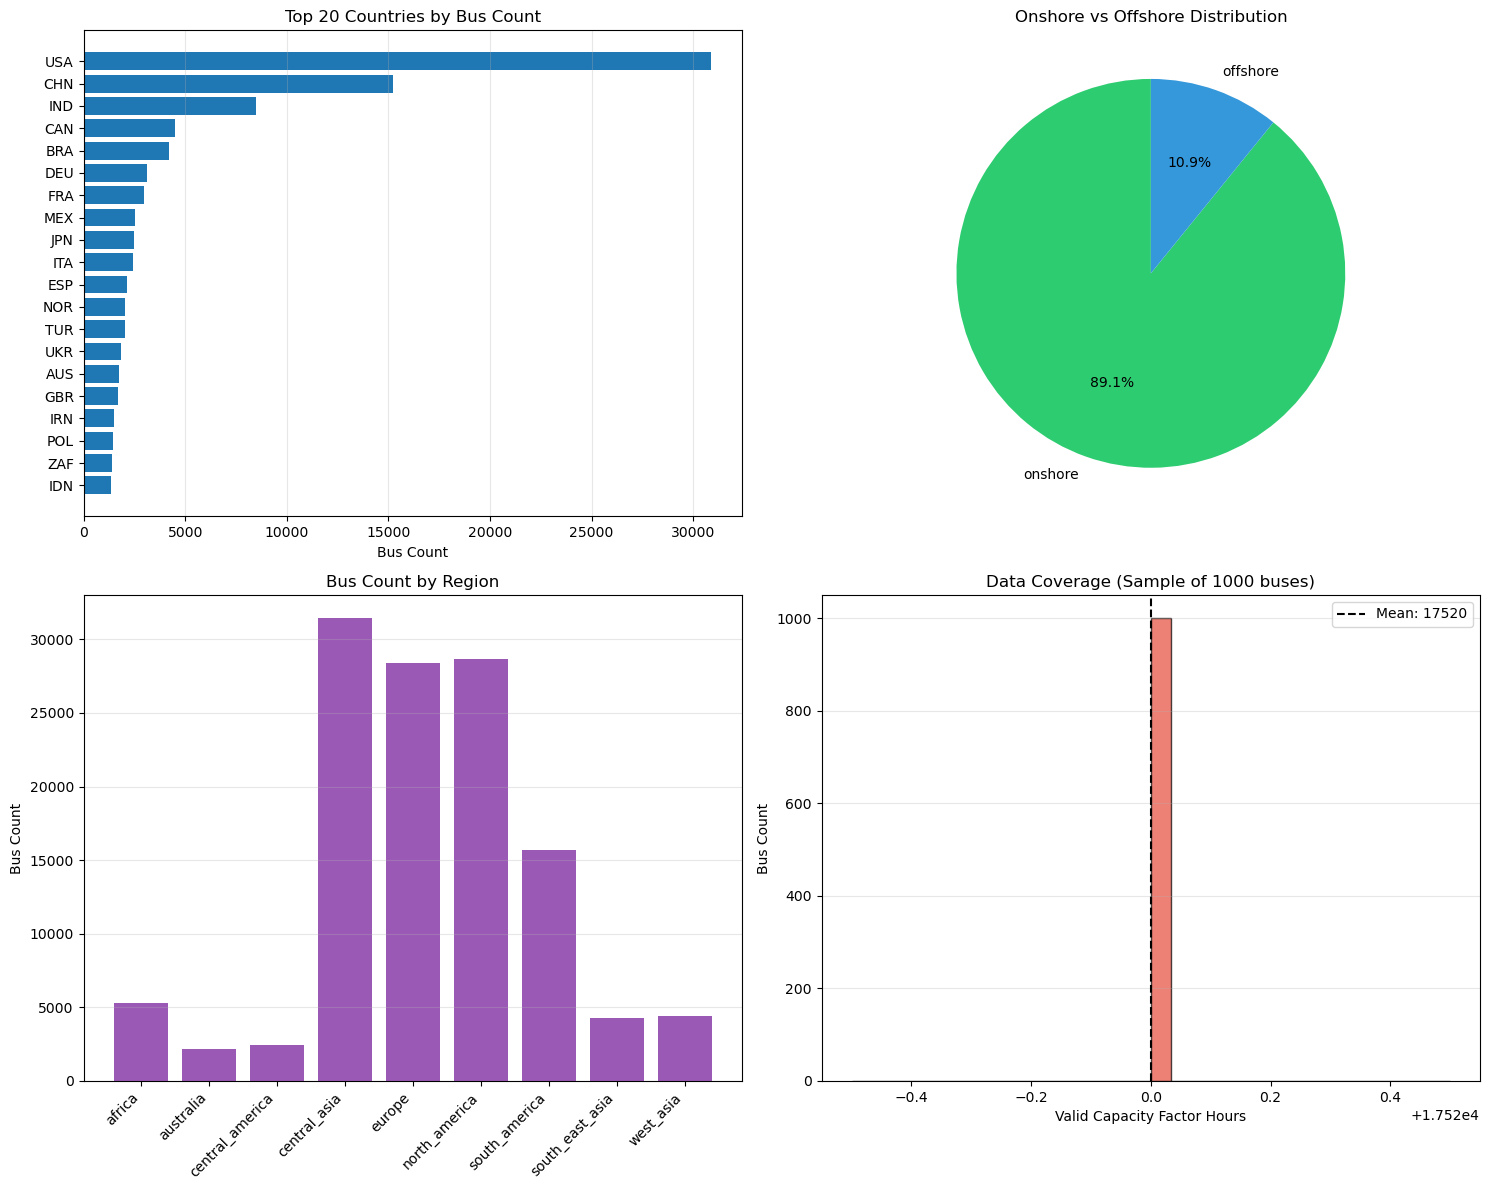

In [20]:
# 4.4 Visualize results

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Top 20 countries by bus count
if "report_df" in locals():
    top20 = report_df.head(20)
    ax = axes[0, 0]
    ax.barh(range(len(top20)), top20["Bus_Count"].values)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20["ISO3"].values)
    ax.set_xlabel("Bus Count")
    ax.set_title("Top 20 Countries by Bus Count")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)

# Plot 2: Technology distribution (onshore vs offshore)
if gdf_merged is not None:
    ax = axes[0, 1]
    tech_dist = gdf_merged["onshore_offshore"].value_counts()
    colors = ["#2ecc71", "#3498db"]
    ax.pie(
        tech_dist.values,
        labels=tech_dist.index,
        autopct="%1.1f%%",
        colors=colors,
        startangle=90,
    )
    ax.set_title("Onshore vs Offshore Distribution")

# Plot 3: Regional distribution (buses per region)
if "merge_metadata" in locals():
    ax = axes[1, 0]
    regions_list = list(merge_metadata["regional_bus_counts"].keys())
    buses_list = list(merge_metadata["regional_bus_counts"].values())
    ax.bar(range(len(regions_list)), buses_list, color="#9b59b6")
    ax.set_xticks(range(len(regions_list)))
    ax.set_xticklabels(regions_list, rotation=45, ha="right")
    ax.set_ylabel("Bus Count")
    ax.set_title("Bus Count by Region")
    ax.grid(axis="y", alpha=0.3)

# Plot 4: Data quality - Buses with data coverage
if ds_merged is not None and gdf_merged is not None:
    ax = axes[1, 1]

    # Count valid capacity factors per bus (non-NaN)
    valid_cf_counts = []
    for bus in ds_merged.coords["bus"].values[
        : min(1000, len(ds_merged.coords["bus"]))
    ]:
        try:
            bus_data = ds_merged.sel(bus=bus)
            valid_cf = (~np.isnan(bus_data["capacity_factor"].values)).sum()
            valid_cf_counts.append(valid_cf)
        except:
            pass

    if valid_cf_counts:
        ax.hist(valid_cf_counts, bins=30, color="#e74c3c", edgecolor="black", alpha=0.7)
        ax.set_xlabel("Valid Capacity Factor Hours")
        ax.set_ylabel("Bus Count")
        ax.set_title("Data Coverage (Sample of 1000 buses)")
        ax.axvline(
            np.mean(valid_cf_counts),
            color="black",
            linestyle="--",
            label=f"Mean: {np.mean(valid_cf_counts):.0f}",
        )
        ax.legend()
        ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    RESOURCES_DIR / "renewable_profiles_merge_summary.png", dpi=150, bbox_inches="tight"
)
print("✓ Saved summary plot to resources/renewable_profiles_merge_summary.png")
plt.show()

In [21]:
# 4.5 Final summary and documentation

print("\n" + "=" * 70)
print("MERGE & VALIDATION COMPLETE")
print("=" * 70)

print("\n📊 MERGE SUMMARY:")
if "merge_metadata" in locals():
    print(f"  Regions merged: {len(merge_metadata['regions_processed'])}")
    print(f"  Total buses: {merge_metadata['total_buses']}")
    print(f"  Countries with data: {len(merge_metadata['iso3_counts'])}")
    print(f"  Merge timestamp: {merge_metadata['merge_timestamp']}")

print("\n✅ VALIDATION RESULTS:")
for check_name, check_result in validation_checks.items():
    status = "PASS ✓" if check_result.get("passed", False) else "FAIL ✗"
    print(f"  {check_name}: {status}")

print("\n📁 OUTPUT FILES:")
print(f"  • {output_nc_file} ({file_size_mb:.1f} MB)")
print(f"  • {output_geojson_file}")
print(f"  • {output_report_file}")
print("  • resources/renewable_profiles_merge_summary.png")

print("\n🌍 COUNTRY COVERAGE:")
if "iso3_valid_in_merged" in locals():
    print(
        f"  Coverage: {len(iso3_valid_in_merged)}/{len(valid_iso3_codes_pycountry)} countries ({len(iso3_valid_in_merged) / len(valid_iso3_codes_pycountry) * 100:.1f}%)"
    )

print("\n✨ MERGE STRATEGY HIGHLIGHTS")
print("=" * 70)
print("Global Grid Approach:")
print("  • Created unified 0.25° global grid covering entire world")
print("  • Placed all regional potential data into corresponding grid cells")
print("  • Filled with NaN where no data available")
print("\nResult: Single comprehensive .nc file containing:")
print(
    "  ✓ All bus-level variables (capacity_factor, p_nom_max, avg_cf, weight, data_quality_flag)"
)
print("  ✓ Global potential grid (y_grid, x_grid, technology)")
print("  ✓ All bus geometries + country codes in .geojson")
print("\nBenefits:")
print("  ✓ Unified dataset - no need to access multiple files")
print("  ✓ Standard gridded format ready for analysis/interpolation")
print("  ✓ Can use numpy/xarray operations on global grid")
print("  ✓ Cleaner API - all data in one place")

print("\n📝 USING THE MERGED DATA")
print("=" * 70)
print("Load and explore:")
print("  ds = xr.open_dataset('data/renewable_profiles_global_merged.nc')")
print("  gdf = gpd.read_file('data/renewable_profiles_global_merged.geojson')")
print("\nAccess bus-level data:")
print("  cf = ds['capacity_factor']  # [bus, technology, hour]")
print("  p_max = ds['p_nom_max']     # [bus, technology]")
print("\nAccess global potential grid:")
print("  pot = ds['potential']        # [y_grid, x_grid, technology]")
print("  pot_data = pot.where(~np.isnan(pot), drop=True)  # Drop NaN regions")
print("\n" + "=" * 70)


MERGE & VALIDATION COMPLETE

📊 MERGE SUMMARY:
  Regions merged: 9
  Total buses: 122831
  Countries with data: 194
  Merge timestamp: 2026-05-27T11:51:25.801922

✅ VALIDATION RESULTS:
  Bus count match: PASS ✓
  GeoJSON-NetCDF count match: PASS ✓
  Technology dimension: PASS ✓
  Hour dimension: PASS ✓
  No duplicate bus_ids: FAIL ✗

📁 OUTPUT FILES:
  • ..\..\data\renewable_profiles_global_merged.nc (116.3 MB)
  • ..\..\data\renewable_profiles_global_merged.geojson
  • ..\..\resources\renewable_profiles_merge_report.json
  • resources/renewable_profiles_merge_summary.png

🌍 COUNTRY COVERAGE:
  Coverage: 194/249 countries (77.9%)

✨ MERGE STRATEGY HIGHLIGHTS
Global Grid Approach:
  • Created unified 0.25° global grid covering entire world
  • Placed all regional potential data into corresponding grid cells
  • Filled with NaN where no data available

Result: Single comprehensive .nc file containing:
  ✓ All bus-level variables (capacity_factor, p_nom_max, avg_cf, weight, data_quality_fl